# Unit 1: CNN基础理论与PyTorch入门

## 学习目标
- 理解卷积神经网络的基本概念与工作原理
- 掌握PyTorch张量的基本操作
- 了解CNN核心组件：卷积、池化、激活函数
- 学会使用PyTorch进行基础张量运算

## 参考资源
- [PyTorch官方文档 - Tensors](https://pytorch.org/docs/stable/tensors.html)
- [PyTorch教程 - What is PyTorch?](https://pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html)
- [CNN可视化解释](https://poloclub.github.io/cnn-explainer/)

## 1.1 卷积神经网络概述

卷积神经网络(Convolutional Neural Network, CNN)是一种专门用于处理具有网格结构数据(如图像)的深度学习模型。

### CNN的核心思想
1. **局部连接**：每个神经元只与输入数据的局部区域连接
2. **权值共享**：同一个卷积核在输入数据上滑动，共享相同的权重
3. **空间下采样**：通过池化操作逐步减小特征图的空间尺寸

### CNN的典型结构
```
输入图像 → 卷积层 → 激活函数 → 池化层 → 卷积层 → 激活函数 → 池化层 → 全连接层 → 输出
```

## 1.2 PyTorch环境检查

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA版本: {torch.version.cuda}")
    print(f"GPU设备: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    # 检查当前电脑是否支持MPS设备
    print(f"MPS是否可用: {torch.backends.mps.is_available()}")
    # 检查pytorch是否已构建MPS设备
    print(f"MPS是否已构建: {torch.backends.mps.is_built()}")


PyTorch版本: 2.12.0
CUDA是否可用: False
MPS是否可用: True
MPS是否已构建: True


## 1.3 PyTorch张量基础

张量(Tensor)是PyTorch中最基本的数据结构，类似于NumPy的ndarray，但支持GPU加速和自动求导。

In [34]:
print("=" * 60)
print("1.3.1 张量的创建")
print("=" * 60)

scalar_tensor = torch.tensor(5.0)
print(f"标量张量: {scalar_tensor}, 形状: {scalar_tensor.shape}")

vector_tensor = torch.tensor([1.0, 2.0, 3.0])
print(f"向量张量: {vector_tensor}, 形状: {vector_tensor.shape}")

matrix_tensor = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(f"矩阵张量:\n{matrix_tensor}, 形状: {matrix_tensor.shape}")

random_tensor = torch.randn(3, 4)
print(f"随机张量(标准正态分布):\n{random_tensor}")

zeros_tensor = torch.zeros(2, 3)
print(f"全零张量:\n{zeros_tensor}")

ones_tensor = torch.ones(2, 3)
print(f"全一张量:\n{ones_tensor}")

1.3.1 张量的创建
标量张量: 5.0, 形状: torch.Size([])
向量张量: tensor([1., 2., 3.]), 形状: torch.Size([3])
矩阵张量:
tensor([[1., 2.],
        [3., 4.]]), 形状: torch.Size([2, 2])
随机张量(标准正态分布):
tensor([[-0.3937,  0.2553,  2.2516, -1.1936],
        [ 1.1518, -0.3982,  1.3464,  0.8635],
        [ 0.6121, -0.5497, -0.6982,  0.2447]])
全零张量:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
全一张量:
tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [35]:
print("=" * 60)
print("1.3.2 张量的基本操作")
print("=" * 60)

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
y = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print(f"x:\n{x}")
print(f"y:\n{y}")
print(f"x + y:\n{x + y}")
print(f"x * y (逐元素相乘):\n{x * y}")
print(f"x @ y (矩阵乘法):\n{x @ y}")
print(f"x.mean(): {x.mean()}")
print(f"x.sum(): {x.sum()}")
print(f"x.max(): {x.max()}")

1.3.2 张量的基本操作
x:
tensor([[1., 2.],
        [3., 4.]])
y:
tensor([[5., 6.],
        [7., 8.]])
x + y:
tensor([[ 6.,  8.],
        [10., 12.]])
x * y (逐元素相乘):
tensor([[ 5., 12.],
        [21., 32.]])
x @ y (矩阵乘法):
tensor([[19., 22.],
        [43., 50.]])
x.mean(): 2.5
x.sum(): 10.0
x.max(): 4.0


In [36]:
print("=" * 60)
print("1.3.3 张量的形状变换")
print("=" * 60)

x = torch.arange(12)
print(f"原始张量: {x}, 形状: {x.shape}")

x_reshaped = x.reshape(3, 4)
print(f"重塑后:\n{x_reshaped}, 形状: {x_reshaped.shape}")

x_transposed = x_reshaped.t()
print(f"转置后:\n{x_transposed}, 形状: {x_transposed.shape}")

x_squeezed = torch.zeros(1, 3, 1, 4)
print(f"压缩前形状: {x_squeezed.shape}")
print(f"压缩后形状: {x_squeezed.squeeze().shape}")

1.3.3 张量的形状变换
原始张量: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), 形状: torch.Size([12])
重塑后:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]), 形状: torch.Size([3, 4])
转置后:
tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]]), 形状: torch.Size([4, 3])
压缩前形状: torch.Size([1, 3, 1, 4])
压缩后形状: torch.Size([3, 4])


## 1.4 卷积运算原理

卷积是CNN的核心操作。卷积核(kernel/filter)在输入数据上滑动，计算局部区域的加权和。

### 关键参数
- **卷积核大小(kernel_size)**：卷积核的空间尺寸
- **步长(stride)**：卷积核每次滑动的步长
- **填充(padding)**：在输入边缘添加的零值数量

### 输出尺寸计算公式
$$ \text{output\_size} = \left\lfloor \frac{\text{input\_size} + 2 \times \text{padding} - \text{kernel\_size}}{\text{stride}} \right\rfloor + 1 $$

**Valid 卷积**（无填充）：`padding = 0`，输出会缩小
    $$\text{output\_size} = \left\lfloor\frac{\text{input\_size} - \text{kernel\_size} + 1}{\text{stride}}\right\rfloor + 1$$

`stride = 1`：
    $$\text{output\_size} = \text{input\_size} - \text{kernel\_size} + 1$$


In [37]:
print("=" * 60)
print("1.4.1 手动实现2D卷积")
print("=" * 60)

def conv2d_manual(input_matrix, kernel):
    """
    手动实现2D卷积操作
    
    参数:
        input_matrix: 输入矩阵 (H, W)
        kernel: 卷积核 (kH, kW)
    返回:
        output: 卷积结果
    """
    input_h, input_w = input_matrix.shape
    kernel_h, kernel_w = kernel.shape
    
    output_h = input_h - kernel_h + 1
    output_w = input_w - kernel_w + 1
    
    output = torch.zeros(output_h, output_w)
    
    for i in range(output_h):
        for j in range(output_w):
            output[i, j] = (input_matrix[i:i+kernel_h, j:j+kernel_w] * kernel).sum()
    
    return output

input_img = torch.tensor([
    [1.0, 2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0, 8.0],
    [9.0, 10.0, 11.0, 12.0],
    [13.0, 14.0, 15.0, 16.0]
])

kernel = torch.tensor([
    [1.0, 0.0],
    [0.0, -1.0]
])

conv_result = conv2d_manual(input_img, kernel)
print(f"输入矩阵:\n{input_img}")
print(f"卷积核:\n{kernel}")
print(f"卷积结果:\n{conv_result}")

1.4.1 手动实现2D卷积
输入矩阵:
tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.],
        [13., 14., 15., 16.]])
卷积核:
tensor([[ 1.,  0.],
        [ 0., -1.]])
卷积结果:
tensor([[-5., -5., -5.],
        [-5., -5., -5.],
        [-5., -5., -5.]])


In [38]:
print("=" * 60)
print("1.4.2 使用PyTorch实现2D卷积")
print("=" * 60)

import torch.nn.functional as F

# 为输入图像添加batch维度和channel维度，使其形状从(H, W)变为(1, 1, H, W)
# 这是PyTorch卷积操作要求的4D输入格式：(batch_size, channels, height, width)
input_tensor = input_img.unsqueeze(0).unsqueeze(0)

# 为卷积核添加out_channel维度和in_channel维度，使其形状从(H, W)变为(1, 1, H, W)
# 这是PyTorch卷积核要求的4D格式：(out_channels, in_channels/groups, kernel_height, kernel_width)
kernel_tensor = kernel.unsqueeze(0).unsqueeze(0)

print(f"输入张量形状: {input_tensor.shape}")
print(f"卷积核形状: {kernel_tensor.shape}")

# F.conv2d 中的 2d 本身就指明了： 总是在最后两个空间维度（Height 和 Width）上执行卷积 
# 而不是在其他维度上执行卷积
conv_output = F.conv2d(input_tensor, kernel_tensor)
print(f"PyTorch卷积结果:\n{conv_output.squeeze()}")

1.4.2 使用PyTorch实现2D卷积
输入张量形状: torch.Size([1, 1, 4, 4])
卷积核形状: torch.Size([1, 1, 2, 2])
PyTorch卷积结果:
tensor([[-5., -5., -5.],
        [-5., -5., -5.],
        [-5., -5., -5.]])


In [39]:
print("=" * 60)
print("1.4.2 使用PyTorch实现2D卷积")
print("=" * 60)

import torch.nn.functional as F

input_img = torch.randn(1, 3, 4, 4)
kernel = torch.randn(1, 3, 2, 2)


# 多通道卷积最后求和，是为了将不同通道上提取到的局部特征融合为一个综合特征值，
# 从而保证输出在空间上是一个紧凑的二维特征图，而不是散乱的一堆数据。
output = F.conv2d(input_img, kernel)
print(f"输出张量形状: {output.shape}")




1.4.2 使用PyTorch实现2D卷积
输出张量形状: torch.Size([1, 1, 3, 3])


## 1.5 池化操作

池化(Pooling)用于降低特征图的空间尺寸，减少参数数量，提高模型的平移不变性。

### 常见池化类型
- **最大池化(Max Pooling)**：取窗口内的最大值
- **平均池化(Average Pooling)**：取窗口内的平均值

In [40]:
print("=" * 60)
print("1.5 池化操作演示")
print("=" * 60)

x = torch.tensor([
    [1.0, 3.0, 2.0, 4.0],
    [5.0, 6.0, 1.0, 2.0],
    [3.0, 2.0, 7.0, 8.0],
    [9.0, 1.0, 2.0, 4.0]
])

x_input = x.unsqueeze(0).unsqueeze(0)

max_pool_output = F.max_pool2d(x_input, kernel_size=2, stride=2)
print(f"输入:\n{x}")
print(max_pool_output.shape)
print(f"最大池化结果(2x2):\n{max_pool_output.squeeze()}")

avg_pool_output = F.avg_pool2d(x_input, kernel_size=2, stride=2)
print(avg_pool_output.shape)
print(f"平均池化结果(2x2):\n{avg_pool_output.squeeze()}")

1.5 池化操作演示
输入:
tensor([[1., 3., 2., 4.],
        [5., 6., 1., 2.],
        [3., 2., 7., 8.],
        [9., 1., 2., 4.]])
torch.Size([1, 1, 2, 2])
最大池化结果(2x2):
tensor([[6., 4.],
        [9., 8.]])
torch.Size([1, 1, 2, 2])
平均池化结果(2x2):
tensor([[3.7500, 2.2500],
        [3.7500, 5.2500]])


## 1.6 激活函数

激活函数为神经网络引入非线性，使模型能够学习复杂的模式。

### 常用激活函数
- **ReLU**: $f(x) = \max(0, x)$
- **Sigmoid**: $f(x) = \frac{1}{1 + e^{-x}}$
- **Tanh**: $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

### 绘制激活函数的图像


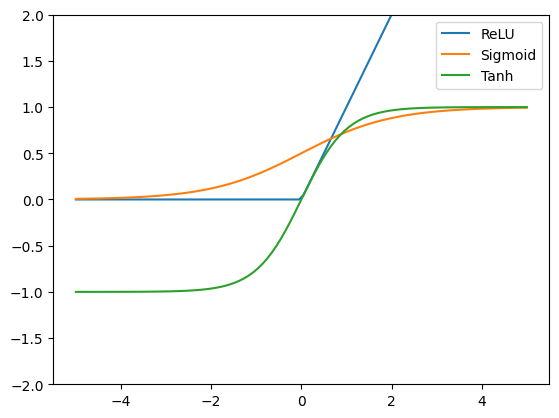

In [41]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y_relu = np.maximum(0, x)
y_sigmoid = 1 / (1 + np.exp(-x))
y_tanh = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
plt.ylim(-2, 2)

plt.plot(x, y_relu, label='ReLU')
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.legend()
plt.show()

1.6 激活函数可视化


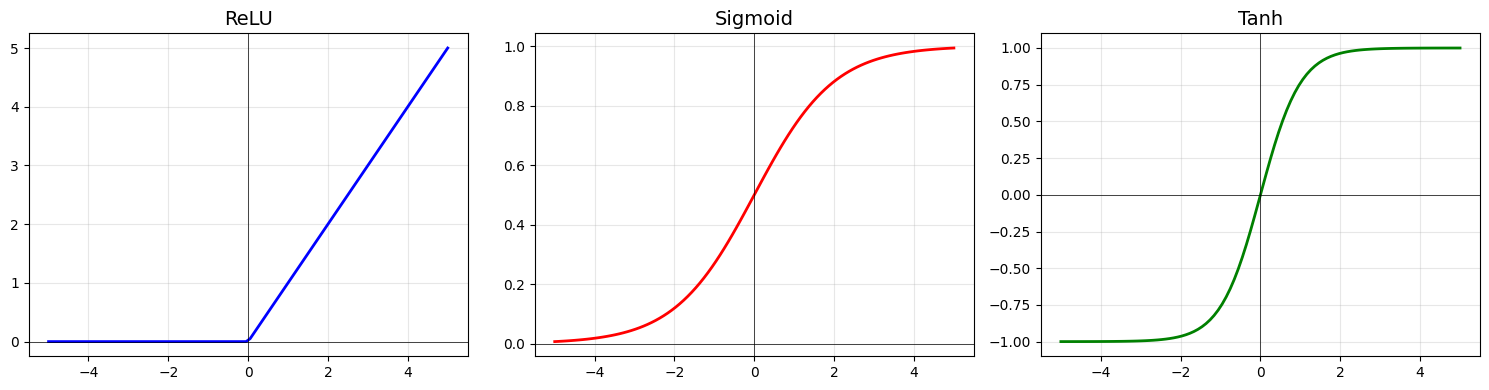

In [42]:
print("=" * 60)
print("1.6 激活函数可视化")
print("=" * 60)

x = torch.linspace(-5, 5, 100)

relu_out = torch.relu(x)
sigmoid_out = torch.sigmoid(x)
tanh_out = torch.tanh(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x.numpy(), relu_out.numpy(), 'b-', linewidth=2)
axes[0].set_title('ReLU', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

axes[1].plot(x.numpy(), sigmoid_out.numpy(), 'r-', linewidth=2)
axes[1].set_title('Sigmoid', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

axes[2].plot(x.numpy(), tanh_out.numpy(), 'g-', linewidth=2)
axes[2].set_title('Tanh', fontsize=14)
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[2].axvline(x=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 1.7 设备管理(CPU/GPU)

PyTorch支持将张量和模型移动到GPU上进行加速计算。

In [45]:
print("=" * 60)
print("1.7 设备管理")
print("=" * 60)

from utils import get_device

device = get_device()
print(f"当前设备: {device}")

x_cpu = torch.randn(1000, 1000)
x_gpu = x_cpu.to(device)
print(f"张量所在设备: {x_gpu.device}")

import time

start = time.time()
for _ in range(1000):
    result_cpu = x_cpu @ x_cpu
cpu_time = time.time() - start
print(f"CPU计算时间: {cpu_time:.4f}秒")

if torch.cuda.is_available():
    start = time.time()
    for _ in range(1000):
        result_gpu = x_gpu @ x_gpu
    torch.cuda.synchronize()
    gpu_time = time.time() - start
    print(f"GPU计算时间: {gpu_time:.4f}秒")
    print(f"加速比: {cpu_time/gpu_time:.2f}x")
elif torch.backends.mps.is_available():
    start = time.time()
    for _ in range(1000):
        result_gpu = x_gpu @ x_gpu
    torch.mps.synchronize()  # 同步MPS设备，确保所有GPU操作完成后再计时
    gpu_time = time.time() - start
    print(f"MPS计算时间: {gpu_time:.4f}秒")
    print(f"加速比: {cpu_time/gpu_time:.2f}x")


1.7 设备管理
当前设备: mps
张量所在设备: mps:0
CPU计算时间: 1.4152秒
MPS计算时间: 0.9612秒
加速比: 1.47x


## 1.8 综合练习：构建简单的CNN前向传播

In [46]:
print("=" * 60)
print("1.8 简单CNN前向传播演示")
print("=" * 60)

import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        print(f"输入形状: {x.shape}")
        x = self.conv1(x)
        print(f"卷积后形状: {x.shape}")
        x = self.relu(x)
        x = self.pool(x)
        print(f"池化后形状: {x.shape}")
        return x

model = SimpleCNN()
print(f"模型结构:\n{model}")

dummy_input = torch.randn(1, 1, 8, 8)
output = model(dummy_input)
print(f"\n最终输出形状: {output.shape}")

1.8 简单CNN前向传播演示
模型结构:
SimpleCNN(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
输入形状: torch.Size([1, 1, 8, 8])
卷积后形状: torch.Size([1, 4, 8, 8])
池化后形状: torch.Size([1, 4, 4, 4])

最终输出形状: torch.Size([1, 4, 4, 4])


## 本章小结

本单元我们学习了：
1. CNN的基本概念和工作原理
2. PyTorch张量的创建与基本操作
3. 卷积、池化、激活函数的原理与实现
4. CPU/GPU设备管理
5. 简单CNN的前向传播过程

## 练习建议
1. 尝试修改卷积核的大小和参数，观察输出变化
2. 比较不同激活函数的特点
3. 练习张量的各种形状变换操作
4. 尝试构建不同结构的简单CNN

## 下一步
进入Unit 2，深入学习PyTorch的自动求导机制和张量高级操作。